In [15]:
#%pip install pandas

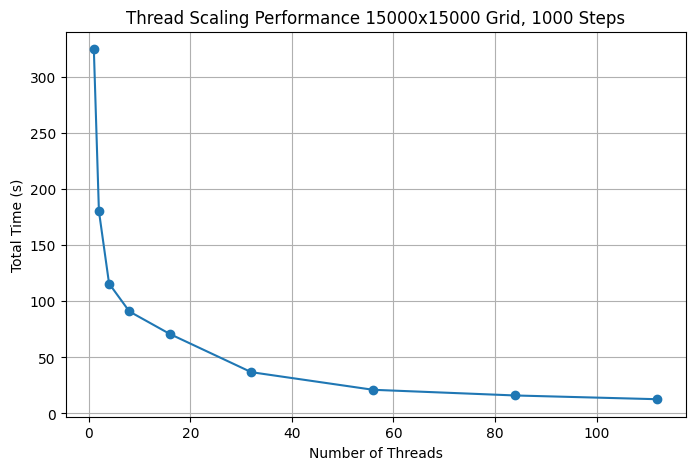

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import re
import os

# Pattern to match your CSV files
files = glob.glob("./thread_scaling/thread_scaling_*_threads.csv")

data = []
for f in files:
    # Extract number of threads from filename using regex

    match = re.search(r"thread_scaling_(\d+)_threads\.csv", f)
    if match:
        threads = int(match.group(1))
        df = pd.read_csv(f)
        total_time = df["Mean_total_time"].iloc[0]
        data.append((threads, total_time))
# Convert to DataFrame
results = pd.DataFrame(data, columns=["Threads", "Total_time"])
results.sort_values("Threads", inplace=True)

# Plot
plt.figure(figsize=(8,5))
plt.plot(results["Threads"], results["Total_time"], marker="o")
plt.xlabel("Number of Threads")
plt.ylabel("Total Time (s)")
plt.title("Thread Scaling Performance 15000x15000 Grid, 1000 Steps")
plt.grid(True)
plt.show()

['./thread_scaling/thread_scaling_4_threads.csv', './thread_scaling/thread_scaling_8_threads.csv', './thread_scaling/thread_scaling_2_threads.csv', './thread_scaling/thread_scaling_84_threads.csv', './thread_scaling/thread_scaling_16_threads.csv', './thread_scaling/thread_scaling_1_threads.csv', './thread_scaling/thread_scaling_56_threads.csv', './thread_scaling/thread_scaling_32_threads.csv', './thread_scaling/thread_scaling_112_threads.csv']


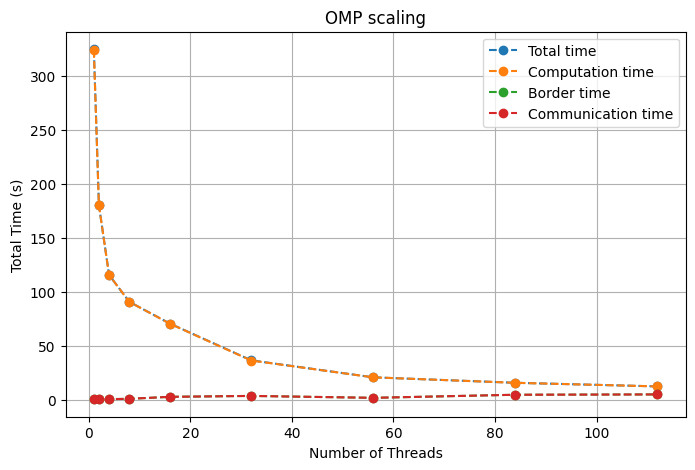

In [17]:
filess_multi = glob.glob(r"./thread_scaling/thread_scaling_*_threads.csv")
print(filess_multi)
dataa_multi = []

for f in filess_multi:
    # Extract number of threads from filename using regex
    filename = os.path.basename(f)
    match = re.search(r"thread_scaling_(\d+)_threads\.csv", filename)
    if match:
        threads = int(match.group(1))
        df = pd.read_csv(f)
        df.columns = df.columns.str.strip()

        total_time = df["Mean_total_time"].iloc[0]
        computation_time  = df["Mean_Computation_time"].iloc[0]
        border_time = df["Mean_Border_time"].iloc[0]
        communication_time  = df["Mean_Communication_time"].iloc[0]

        dataa_multi.append((threads, total_time, computation_time, border_time, communication_time))

# Convert to DataFrame
resultss_multi = pd.DataFrame(dataa_multi, columns=["Threads", "Mean_total_time", 
                                      "Mean_Computation_time", "Mean_Border_time", "Mean_Communication_time"])
resultss_multi.sort_values("Threads", inplace=True)

# Plot
plt.figure(figsize=(8,5))
plt.plot(resultss_multi["Threads"], resultss_multi["Mean_total_time"], marker="o", label="Total time", linestyle="--")
plt.plot(resultss_multi["Threads"], resultss_multi["Mean_Computation_time"], marker="o", label="Computation time", linestyle="--")
plt.plot(resultss_multi["Threads"], resultss_multi["Mean_Border_time"], marker="o", label="Border time", linestyle="--")
plt.plot(resultss_multi["Threads"], resultss_multi["Mean_Communication_time"], marker="o", label="Communication time", linestyle="--")

# Labels and grid
plt.xlabel("Number of Threads")
plt.ylabel("Total Time (s)")
plt.title("OMP scaling")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
print(files)

['./thread_scaling/thread_scaling_4_threads.csv', './thread_scaling/thread_scaling_8_threads.csv', './thread_scaling/thread_scaling_2_threads.csv', './thread_scaling/thread_scaling_84_threads.csv', './thread_scaling/thread_scaling_16_threads.csv', './thread_scaling/thread_scaling_1_threads.csv', './thread_scaling/thread_scaling_56_threads.csv', './thread_scaling/thread_scaling_32_threads.csv', './thread_scaling/thread_scaling_112_threads.csv']


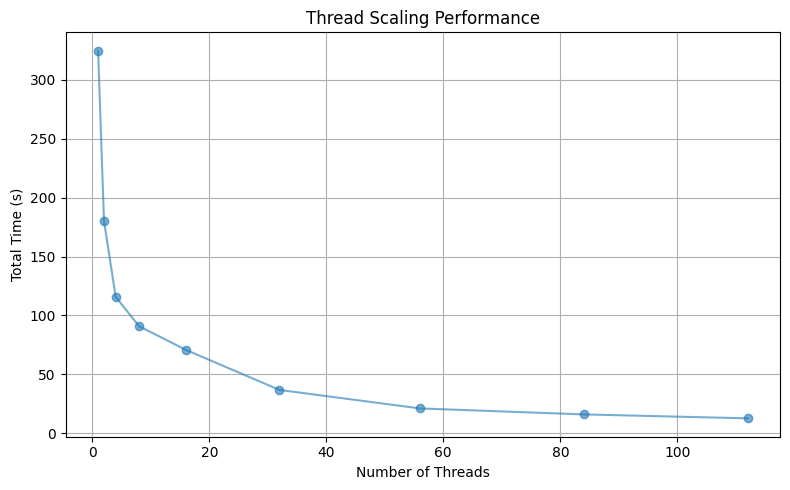

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import re
import os

files = glob.glob(
    r"./thread_scaling/thread_scaling_*_threads.csv"
)

# Exract and plot total times
data = []

for f in files:
    filename = os.path.basename(f)

    match = re.search(r"thread_scaling_(\d+)_threads\.csv", filename)
    if match:
        threads = int(match.group(1))

        df = pd.read_csv(f)
        df.columns = df.columns.str.strip()

        total_time = df["Mean_total_time"].iloc[0]

        data.append((threads, total_time))

results = pd.DataFrame(data, columns=["Threads", "Total_time"])
results = results.sort_values("Threads")

plt.figure(figsize=(8, 5))
plt.plot(results["Threads"], results["Total_time"], marker="o", alpha=0.6)
plt.xlabel("Number of Threads")
plt.ylabel("Total Time (s)")
plt.title("Thread Scaling Performance")
plt.grid(True)
plt.tight_layout()
plt.show()

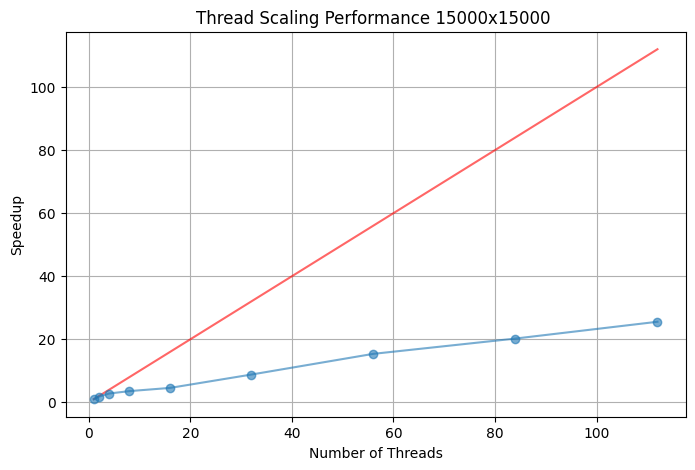

In [20]:
# plotting speedup
plt.figure(figsize=(8,5))
plt.plot(results["Threads"], results["Threads"], color = 'red', alpha=0.6)
# dividing serial time by parallel time to get speedup
plt.plot(results["Threads"], results["Total_time"].iloc[0]/results["Total_time"], marker="o", alpha=0.6)
plt.xlabel("Number of Threads")
plt.ylabel("Speedup")
plt.title("Thread Scaling Performance 15000x15000 ")
plt.grid(True)
plt.show()

# this bad speedup can be explained by the fact that by setting omp_threads to close,
# the overhead of thread management and synchronization becomes significant compared to 
# the actual computation time
# because the buses that connect the cores in each socket are filled and not enough
# to handle all these data

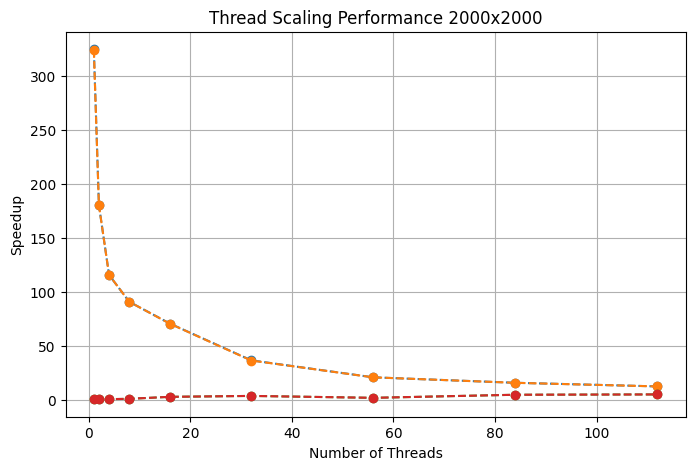

In [21]:
file_multi_2000 = glob.glob(r"./thread_scaling/thread_scaling_*_threads.csv")

data_multi_2000 = []

for f in file_multi_2000:
    # Extract number of threads from filename using regex
    filename = os.path.basename(f)
    match = re.search(r"thread_scaling_(\d+)_threads\.csv", filename)
    if match:
        threads = int(match.group(1))
        df = pd.read_csv(f)
        df.columns = df.columns.str.strip()

        total_time = df["Mean_total_time"].iloc[0]
        computation_time  = df["Mean_Computation_time"].iloc[0]
        border_time = df["Mean_Border_time"].iloc[0]
        communication_time  = df["Mean_Communication_time"].iloc[0]

        data_multi_2000.append((threads, total_time, computation_time, border_time, communication_time))

# Convert to DataFrame
results_multi_2000 = pd.DataFrame(data_multi_2000, columns=["Threads", "Mean_total_time", 
                                      "Mean_Computation_time", "Mean_Border_time", "Mean_Communication_time"])
results_multi_2000.sort_values("Threads", inplace=True)

plt.figure(figsize=(8,5))
plt.plot(results_multi_2000["Threads"], results_multi_2000["Mean_total_time"], marker="o", label="Total time", linestyle="--")
plt.plot(results_multi_2000["Threads"], results_multi_2000["Mean_Computation_time"], marker="o", label="Computation time", linestyle="--")
plt.plot(results_multi_2000["Threads"], results_multi_2000["Mean_Border_time"], marker="o", label="Border time", linestyle="--")
plt.plot(results_multi_2000["Threads"], results_multi_2000["Mean_Communication_time"], marker="o", label="Communication time", linestyle="--")
plt.xlabel("Number of Threads")
plt.ylabel("Speedup")
plt.title("Thread Scaling Performance 2000x2000")
plt.grid(True)
plt.show()

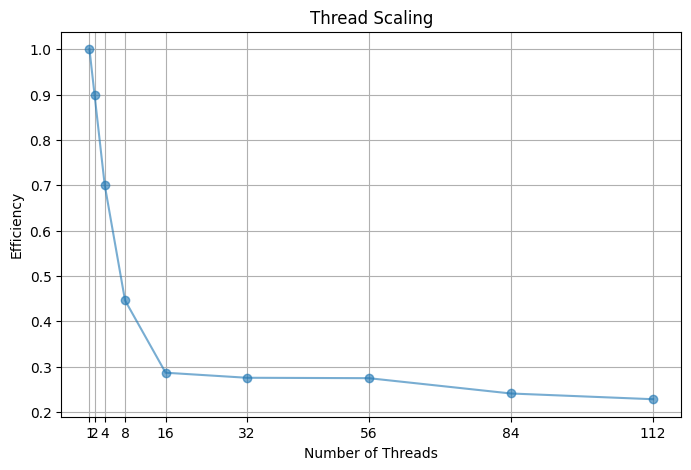

In [22]:
# plotting speedup
plt.figure(figsize=(8,5))
#plt.plot(results["Threads"], results["Threads"], color = 'red')
# dividing serial time by parallel time to get speedup
plt.axes().set_xticks(results["Threads"])
plt.plot(results["Threads"], (results["Total_time"].iloc[0]/results["Total_time"])/results["Threads"], marker="o", alpha=0.6)
plt.xlabel("Number of Threads")
plt.ylabel("Efficiency")
plt.title("Thread Scaling")
plt.grid(True)
plt.show()

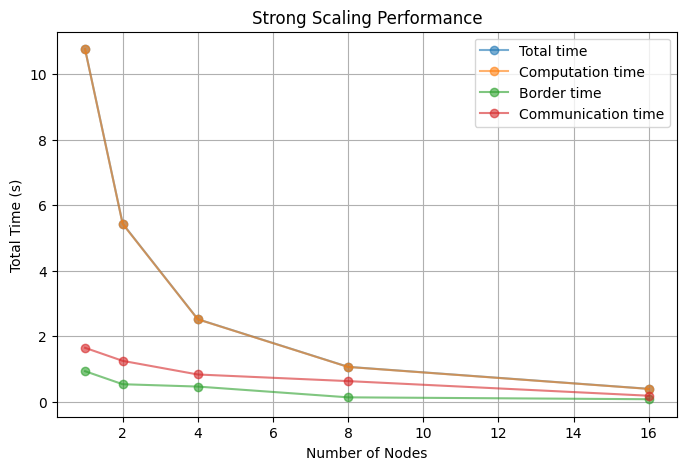

In [23]:
filess = glob.glob(r"./strong_scaling/strong_scaling_*n_*t.csv")

dataa = []

for f in filess:
    # Extract number of threads from filename using regex
    filename = os.path.basename(f)
    match = re.search(r"strong_scaling_(\d+)n_(\d+)t\.csv", filename)
    if match:
        nodes = int(match.group(1))
        tasks = int(match.group(2))
        df = pd.read_csv(f)
        df.columns = df.columns.str.strip()

        total_time = df["Mean_total_time"].iloc[0]
        computation_time  = df["Mean_Computation_time"].iloc[0]
        border_time = df["Mean_Border_time"].iloc[0]
        communication_time  = df["Mean_Communication_time"].iloc[0]
        injection_time = df.get("Mean_Injection_time", pd.Series([0])).iloc[0]

        dataa.append((tasks, nodes, total_time, communication_time, computation_time, border_time, injection_time))

# Convert to DataFrame
resultss = pd.DataFrame(dataa, columns=["Tasks", "Nodes", "Mean_total_time", 
                                      "Mean_Communication_time", "Mean_Computation_time", "Mean_Border_time", "Mean_Injection_time"])
resultss.sort_values("Tasks", inplace=True)

# Plot
plt.figure(figsize=(8,5))
plt.plot(resultss["Nodes"], resultss["Mean_total_time"], marker="o", label="Total time", alpha=0.6)
plt.plot(resultss["Nodes"], resultss["Mean_Computation_time"], marker="o", label="Computation time", alpha=0.6)
plt.plot(resultss["Nodes"], resultss["Mean_Border_time"], marker="o", label="Border time", alpha=0.6)
#plt.plot(resultss["Nodes"], resultss["Mean_Communication_time"], marker="o", label="Communication time")
plt.plot(resultss["Nodes"], resultss["Mean_Communication_time"], marker="o", label="Communication time", alpha=0.6)

# Labels and grid
plt.xlabel("Number of Nodes")
plt.ylabel("Total Time (s)")
plt.title("Strong Scaling Performance")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
print(resultss[['Nodes', 'Mean_Computation_time', 'Mean_Communication_time', 'Mean_Injection_time']])


   Nodes  Mean_Computation_time  Mean_Communication_time  Mean_Injection_time
3      1              10.759322                 1.650665             0.000400
0      2               5.433617                 1.252879             0.000348
2      4               2.520421                 0.836724             0.000279
1      8               1.066197                 0.634935             0.000295
4     16               0.396454                 0.188771             0.000267


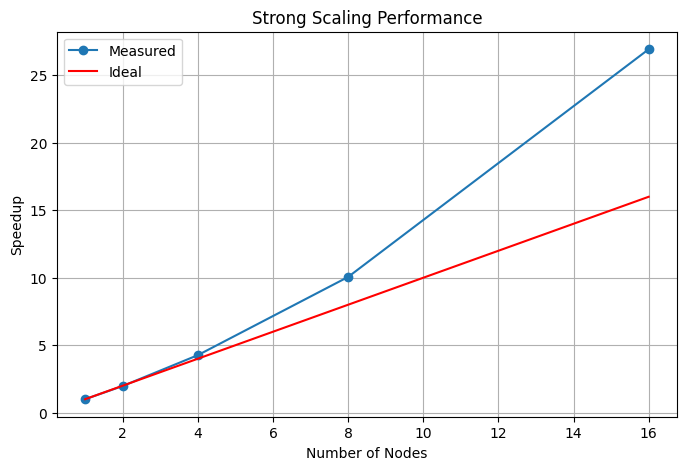

In [25]:
resultsss = resultss[["Tasks", "Nodes", "Mean_total_time"]].copy()
resultsss.sort_values("Tasks", inplace=True)

plt.figure(figsize=(8,5))
plt.plot(
	resultsss["Nodes"],
	resultsss["Mean_total_time"].iloc[0] / resultsss["Mean_total_time"],
	marker="o", label="Measured"
)
plt.plot(resultsss["Nodes"], resultsss["Nodes"], color='red', label='Ideal')
plt.xlabel("Number of Nodes")
plt.ylabel("Speedup")
plt.title("Strong Scaling Performance")
plt.legend()
plt.grid(True)
plt.show()

['./weak_scale/weak_scale_2n_16t.csv', './weak_scale/weak_scale_16n_128t.csv', './weak_scale/weak_scale_8n_64t.csv', './weak_scale/weak_scale_4n_32t.csv', './weak_scale/weak_scale_1n_8t.csv']


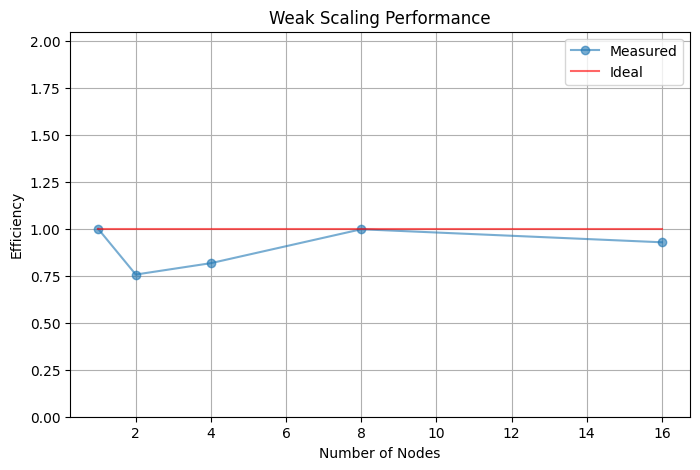

In [26]:
filessss = glob.glob(r"./weak_scale/weak_scale_*n_*t.csv")
print(filessss)
dataaaa = []

for f in filessss:
    filename = os.path.basename(f)
    match = re.search(r"weak_scale_(\d+)n_(\d+)t\.csv", filename)
    if match:
        nodes = int(match.group(1))
        tasks = int(match.group(2))
        df = pd.read_csv(f)
        df.columns = df.columns.str.strip()

        total_time = df["Mean_total_time"].iloc[0]
        computation_time  = df["Mean_Computation_time"].iloc[0]
        border_time = df["Mean_Border_time"].iloc[0]
        communication_time  = df["Mean_Communication_time"].iloc[0]
        injection_time = df.get("Mean_Injection_time", pd.Series([0])).iloc[0]

        dataaaa.append((tasks, nodes, total_time, communication_time, computation_time, border_time, injection_time))

resultsss = pd.DataFrame(dataaaa, columns=["Tasks", "Nodes", "Mean_total_time", "Mean_Communication_time", "Mean_Computation_time", "Mean_Border_time", "Mean_Injection_time"])
resultsss.sort_values("Tasks", inplace=True)

# Plot
# this command is useful to scale the plots in the slides
plt.figure(figsize=(8,5))
plt.ylim(0, max(resultsss["Mean_total_time"].iloc[0]/resultsss["Mean_total_time"])*2.05)
plt.plot(resultsss["Nodes"], resultsss["Mean_total_time"].iloc[0]/resultsss["Mean_total_time"], marker="o", label = "Measured", alpha=0.6)
plt.plot(resultsss["Nodes"],resultsss["Nodes"]/resultsss["Nodes"], color = 'red', label='Ideal', alpha=0.6)

#plt.ylim(0.5, 1.2)  # Tighter range to show efficiency closer to ideal
#plt.plot(resultsss["Nodes"], resultsss["Mean_total_time"].iloc[0]/resultsss["Mean_total_time"], marker="o", label = "Measured")
#plt.plot(resultsss["Nodes"],resultsss["Nodes"]/resultsss["Nodes"], color = 'red', label='Ideal')
plt.xlabel("Number of Nodes")
plt.ylabel("Efficiency")
plt.title("Weak Scaling Performance")
plt.legend()
plt.grid(True)
plt.show()

['./weak_scale_bigger_grid/weak_scale_bigger_grid_16n_128t.csv', './weak_scale_bigger_grid/weak_scale_bigger_grid_2n_16t.csv', './weak_scale_bigger_grid/weak_scale_bigger_grid_4n_32t.csv', './weak_scale_bigger_grid/weak_scale_bigger_grid_1n_8t.csv', './weak_scale_bigger_grid/weak_scale_bigger_grid_8n_64t.csv']


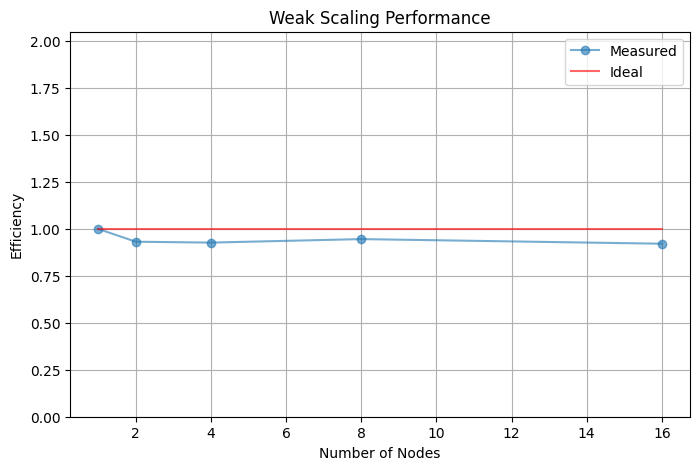

In [27]:
filessss = glob.glob(r"./weak_scale_bigger_grid/weak_scale_bigger_grid_*n_*t.csv")
print(filessss)
dataaaa = []

for f in filessss:
    filename = os.path.basename(f)
    match = re.search(r"weak_scale_bigger_grid_(\d+)n_(\d+)t\.csv", filename)
    if match:
        nodes = int(match.group(1))
        tasks = int(match.group(2))
        df = pd.read_csv(f)
        df.columns = df.columns.str.strip()

        total_time = df["Mean_total_time"].iloc[0]
        computation_time  = df["Mean_Computation_time"].iloc[0]
        border_time = df["Mean_Border_time"].iloc[0]
        communication_time  = df["Mean_Communication_time"].iloc[0]
        injection_time = df.get("Mean_Injection_time", pd.Series([0])).iloc[0]

        dataaaa.append((tasks, nodes, total_time, communication_time, computation_time, border_time, injection_time))

resultsss = pd.DataFrame(dataaaa, columns=["Tasks", "Nodes", "Mean_total_time", "Mean_Communication_time", "Mean_Computation_time", "Mean_Border_time", "Mean_Injection_time"])
resultsss.sort_values("Tasks", inplace=True)

# Plot
# this command is useful to scale the plots in the slides
plt.figure(figsize=(8,5))
plt.ylim(0, max(resultsss["Mean_total_time"].iloc[0]/resultsss["Mean_total_time"])*2.05)
plt.plot(resultsss["Nodes"], resultsss["Mean_total_time"].iloc[0]/resultsss["Mean_total_time"], marker="o", label = "Measured", alpha=0.6)
plt.plot(resultsss["Nodes"],resultsss["Nodes"]/resultsss["Nodes"], color = 'red', label='Ideal', alpha=0.6)

#plt.ylim(0.5, 1.2)  # Tighter range to show efficiency closer to ideal
#plt.plot(resultsss["Nodes"], resultsss["Mean_total_time"].iloc[0]/resultsss["Mean_total_time"], marker="o", label = "Measured")
#plt.plot(resultsss["Nodes"],resultsss["Nodes"]/resultsss["Nodes"], color = 'red', label='Ideal')
plt.xlabel("Number of Nodes")
plt.ylabel("Efficiency")
plt.title("Weak Scaling Performance")
plt.legend()
plt.grid(True)
plt.show()

['./weak_scale_bigger_grid/weak_scale_bigger_grid_16n_128t.csv', './weak_scale_bigger_grid/weak_scale_bigger_grid_2n_16t.csv', './weak_scale_bigger_grid/weak_scale_bigger_grid_4n_32t.csv', './weak_scale_bigger_grid/weak_scale_bigger_grid_1n_8t.csv', './weak_scale_bigger_grid/weak_scale_bigger_grid_8n_64t.csv']


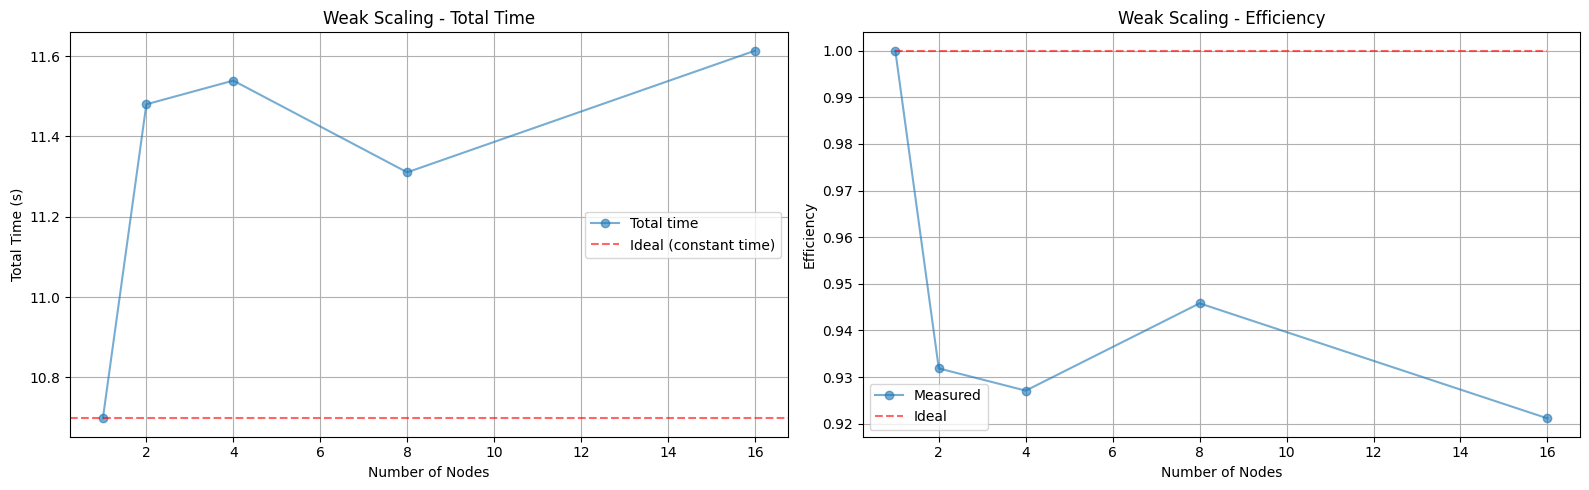

In [28]:

filessss = glob.glob(r"./weak_scale_bigger_grid/weak_scale_bigger_grid_*n_*t.csv")
print(filessss)
dataaaa = []

for f in filessss:
    filename = os.path.basename(f)
    match = re.search(r"weak_scale_bigger_grid_(\d+)n_(\d+)t\.csv", filename)
    if match:
        nodes = int(match.group(1))
        tasks = int(match.group(2))
        df = pd.read_csv(f)
        df.columns = df.columns.str.strip()

        total_time = df["Mean_total_time"].iloc[0]
        computation_time  = df["Mean_Computation_time"].iloc[0]
        border_time = df["Mean_Border_time"].iloc[0]
        communication_time  = df["Mean_Communication_time"].iloc[0]
        injection_time = df.get("Mean_Injection_time", pd.Series([0])).iloc[0]

        dataaaa.append((tasks, nodes, total_time, communication_time, computation_time, border_time, injection_time))
resultsss = pd.DataFrame(dataaaa, columns=["Tasks", "Nodes", "Mean_total_time", "Mean_Communication_time", "Mean_Computation_time", "Mean_Border_time", "Mean_Injection_time"])
resultsss.sort_values("Tasks", inplace=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Weak Scaling Time
ax1.plot(resultsss["Nodes"], resultsss["Mean_total_time"], marker="o", label="Total time", alpha=0.6)
ax1.axhline(y=resultsss["Mean_total_time"].iloc[0], color='red', linestyle='--', label='Ideal (constant time)', alpha=0.6)
ax1.set_xlabel("Number of Nodes")
ax1.set_ylabel("Total Time (s)")
ax1.set_title("Weak Scaling - Total Time")
ax1.legend()
ax1.grid(True)

# Plot 2: Weak Scaling Efficiency (Speedup normalized)
ax2.plot(resultsss["Nodes"], resultsss["Mean_total_time"].iloc[0]/resultsss["Mean_total_time"], marker="o", label="Measured", alpha=0.6)
ax2.plot(resultsss["Nodes"], resultsss["Nodes"]/resultsss["Nodes"], color='red', linestyle='--', label='Ideal', alpha=0.6)
ax2.set_xlabel("Number of Nodes")
ax2.set_ylabel("Efficiency")
ax2.set_title("Weak Scaling - Efficiency")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()